## Stanisław Wojciechowski
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/vyenn/ML2024/blob/main/homework7.ipynb)

Our loss function is
$$
L(y, \lambda) = -y \log(\sigma(\lambda)) - (1 - y) \log(1 - \sigma(\lambda)),
$$
where $\sigma(\lambda) = \frac{1}{1 + e^{-\lambda}} $. Easy calculation shows that
$$
\frac{d}{d\lambda} L(y,\lambda) = σ(λ) - y
$$
and
$$
\frac{\partial^2 }{\partial \lambda^2} L(y,\lambda) = \sigma(\lambda)(1-\sigma(\lambda)) \geq 0.
$$
Thus $L$ is convex in $\lambda$. This means that setting derivative to zero finds the global minimum.


### Scenario A
We have
$$
\frac{d}{dλ}\sum_{i}L(y_i,\lambda) = \sum_i ( σ(\lambda) - y_i ) = n\sigma(\lambda) - m.
$$
Setting it to zero yields $\lambda^* = \sigma^{-1}(\frac{m}{n}) = \log \frac{m}{k}$. Therefore we see that $\lambda^*$ is precisely the log-odds of the positive class in the dataset. It places the constant predictor at the point where the model's predicted positive probability $\sigma(\lambda)$ equals the empirical positive frequency $m/n$.


### Scenario B
Now we have existing predictions $f_i = f_{m-1}(x_i)$. We have
$$
\frac{d}{d\lambda}\sum_{i}L(y_i,f_i+\lambda) = \sum_i ( σ(f_i+\lambda) - y_i ) = \sum_{i=1}^n \sigma(f_i+\lambda) - m.
$$
Setting this to zero gives an implicit equation
$$
\sum_{i=1}^n \sigma(f_i+\lambda^*) = m.
$$
It doesn't have a closed solution in $\lambda$ since a sum of non-identical sigmoids can be a general degree-$n$ polynomial in $e^{-\lambda}$.

## Ploting the binary cross-entropy loss as a function of  $\lambda$ for both scenarios

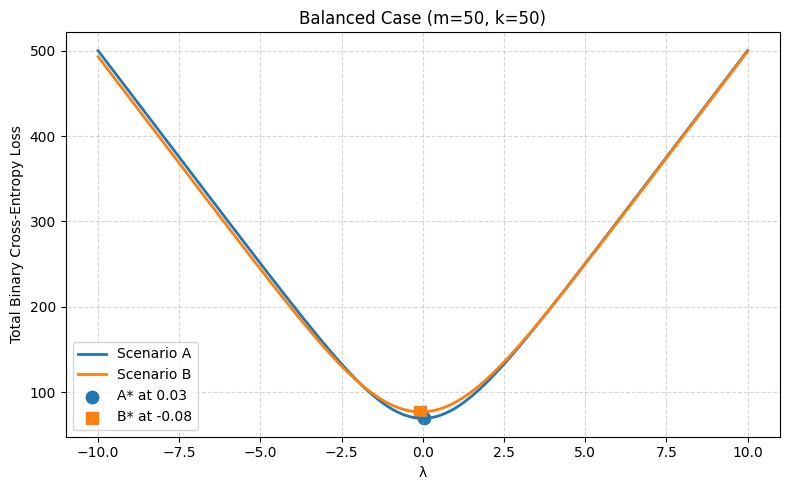

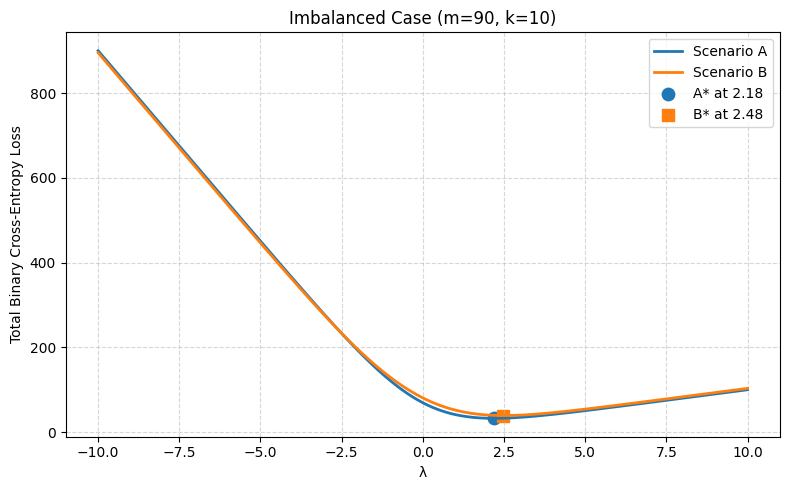

In [2]:
import numpy as np
import matplotlib.pyplot as plt

cases = {
    'balanced': (50, 50),
    'imbalanced': (90, 10)
}

np.random.seed(0)  # for reproducibility

# Grid of lambda values
lambdas = np.linspace(-10, 10, 400)

# Sigmoid and binary cross-entropy loss functions
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def log_loss(y, z):
    sig = sigmoid(z)
    return -y * np.log(sig) - (1 - y) * np.log(1 - sig)

# Loop over cases and plot
for name, (m, k) in cases.items():
    n = m + k
    # Labels: m ones followed by k zeros
    y = np.array([1] * m + [0] * k)
    # Random previous-stage predictions
    f = np.random.randn(n)

    # Compute losses over the lambda grid
    # Scenario A: constant predictor
    loss_A = np.sum(log_loss(y[:, None], lambdas[None, :]), axis=0)
    # Scenario B: additive shift
    loss_B = np.sum(log_loss(y[:, None], f[:, None] + lambdas[None, :]), axis=0)

    # Find minimizing lambdas
    lam_A_opt = lambdas[np.argmin(loss_A)]
    lam_B_opt = lambdas[np.argmin(loss_B)]
    loss_A_opt = np.min(loss_A)
    loss_B_opt = np.min(loss_B)

    # Plot
    plt.figure(figsize=(8, 5))
    plt.plot(lambdas, loss_A, label='Scenario A', linewidth=2)
    plt.plot(lambdas, loss_B, label='Scenario B', linewidth=2)
    plt.scatter([lam_A_opt], [loss_A_opt], marker='o', s=80, label=f'A* at {lam_A_opt:.2f}')
    plt.scatter([lam_B_opt], [loss_B_opt], marker='s', s=80, label=f'B* at {lam_B_opt:.2f}')
    plt.title(f'{name.capitalize()} Case (m={m}, k={k})')
    plt.xlabel('λ')
    plt.ylabel('Total Binary Cross-Entropy Loss')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

## Discussion

Despite the fact that scenario A has a closed form and scenario B doesn't, their loss landscapes look deceptively similar. Both are unimodal. Although there's no closed-form solution in B, the convexity of a graph shows that it's very feasible to find $\lambda^*$ numerically. The difficulty comes from non-linearity of the problem rather than a complex loss landscape.